## Imports and Setup

In [1]:
import os
import random
import warnings
import numpy as np
import polars as pl
import scipy
import sklearn
import plotly
import plotly.express as px
import plotly.graph_objects as go
from statsmodels.stats.outliers_influence import variance_inflation_factor

import plotly.io as pio

pio.renderers.default = "png"
pio.kaleido.scope.default_scale = 2

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"numpy       {np.__version__}")
print(f"polars      {pl.__version__}")
print(f"scipy       {scipy.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"plotly      {plotly.__version__}")

numpy       2.5.2
polars      1.43.2
scipy       1.18.0
scikit-learn 1.9.0
plotly      6.9.0


/var/folders/cz/x56wj7xx759590kg8s44wshm0000gn/T/ipykernel_67956/4209590082.py:16: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_scale is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_scale instead.

  pio.kaleido.scope.default_scale = 2


## Data Loading

In [2]:
RAW_DATA_PATH = "../data/raw/CarPrice_Assignment.csv"

df = pl.read_csv(RAW_DATA_PATH)

print(f"Shape: {df.shape}")
df.head()

Shape: (205, 26)


car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
i64,i64,str,str,str,str,str,str,str,f64,f64,f64,f64,i64,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64
1,3,"""alfa-romero giulia""","""gas""","""std""","""two""","""convertible""","""rwd""","""front""",88.6,168.8,64.1,48.8,2548,"""dohc""","""four""",130,"""mpfi""",3.47,2.68,9.0,111,5000,21,27,13495.0
2,3,"""alfa-romero stelvio""","""gas""","""std""","""two""","""convertible""","""rwd""","""front""",88.6,168.8,64.1,48.8,2548,"""dohc""","""four""",130,"""mpfi""",3.47,2.68,9.0,111,5000,21,27,16500.0
3,1,"""alfa-romero Quadrifoglio""","""gas""","""std""","""two""","""hatchback""","""rwd""","""front""",94.5,171.2,65.5,52.4,2823,"""ohcv""","""six""",152,"""mpfi""",2.68,3.47,9.0,154,5000,19,26,16500.0
4,2,"""audi 100 ls""","""gas""","""std""","""four""","""sedan""","""fwd""","""front""",99.8,176.6,66.2,54.3,2337,"""ohc""","""four""",109,"""mpfi""",3.19,3.4,10.0,102,5500,24,30,13950.0
5,2,"""audi 100ls""","""gas""","""std""","""four""","""sedan""","""4wd""","""front""",99.4,176.6,66.4,54.3,2824,"""ohc""","""five""",136,"""mpfi""",3.19,3.4,8.0,115,5500,18,22,17450.0


## Data Cleaning

### Missing Value Audit

In [3]:
null_counts = df.null_count()
null_summary = (
    null_counts
    .transpose(include_header=True, header_name="column", column_names=["null_count"])
    .filter(pl.col("null_count") > 0)
    .sort("null_count", descending=True)
)

print(f"Columns with nulls: {null_summary.shape[0]} of {df.shape[1]}")
null_summary

Columns with nulls: 0 of 26


column,null_count
str,u32


### Dtype Overview

In [4]:
df.schema

Schema([('car_ID', Int64),
        ('symboling', Int64),
        ('CarName', String),
        ('fueltype', String),
        ('aspiration', String),
        ('doornumber', String),
        ('carbody', String),
        ('drivewheel', String),
        ('enginelocation', String),
        ('wheelbase', Float64),
        ('carlength', Float64),
        ('carwidth', Float64),
        ('carheight', Float64),
        ('curbweight', Int64),
        ('enginetype', String),
        ('cylindernumber', String),
        ('enginesize', Int64),
        ('fuelsystem', String),
        ('boreratio', Float64),
        ('stroke', Float64),
        ('compressionratio', Float64),
        ('horsepower', Int64),
        ('peakrpm', Int64),
        ('citympg', Int64),
        ('highwaympg', Int64),
        ('price', Float64)])

### CarName Inspection

In [5]:
sorted(df["CarName"].unique().to_list())

['Nissan versa',
 'alfa-romero Quadrifoglio',
 'alfa-romero giulia',
 'alfa-romero stelvio',
 'audi 100 ls',
 'audi 100ls',
 'audi 4000',
 'audi 5000',
 'audi 5000s (diesel)',
 'audi fox',
 'bmw 320i',
 'bmw x1',
 'bmw x3',
 'bmw x4',
 'bmw x5',
 'bmw z4',
 'buick century',
 'buick century luxus (sw)',
 'buick century special',
 'buick electra 225 custom',
 'buick opel isuzu deluxe',
 'buick regal sport coupe (turbo)',
 'buick skyhawk',
 'buick skylark',
 'chevrolet impala',
 'chevrolet monte carlo',
 'chevrolet vega 2300',
 'dodge challenger se',
 'dodge colt (sw)',
 'dodge colt hardtop',
 'dodge coronet custom',
 'dodge coronet custom (sw)',
 'dodge d200',
 'dodge dart custom',
 'dodge monaco (sw)',
 'dodge rampage',
 'honda accord',
 'honda accord cvcc',
 'honda accord lx',
 'honda civic',
 'honda civic (auto)',
 'honda civic 1300',
 'honda civic 1500 gl',
 'honda civic cvcc',
 'honda prelude',
 'isuzu D-Max ',
 'isuzu D-Max V-Cross',
 'isuzu MU-X',
 'jaguar xf',
 'jaguar xj',
 'jag

### Categorical Columns Inspection

In [6]:
categorical_cols = [
    "fueltype", "aspiration", "doornumber", "carbody", "drivewheel",
    "enginelocation", "enginetype", "cylindernumber", "fuelsystem"
]

for col in categorical_cols:
    print(f"{col}: {sorted(df[col].unique().to_list())}")

fueltype: ['diesel', 'gas']
aspiration: ['std', 'turbo']
doornumber: ['four', 'two']
carbody: ['convertible', 'hardtop', 'hatchback', 'sedan', 'wagon']
drivewheel: ['4wd', 'fwd', 'rwd']
enginelocation: ['front', 'rear']
enginetype: ['dohc', 'dohcv', 'l', 'ohc', 'ohcf', 'ohcv', 'rotor']
cylindernumber: ['eight', 'five', 'four', 'six', 'three', 'twelve', 'two']
fuelsystem: ['1bbl', '2bbl', '4bbl', 'idi', 'mfi', 'mpfi', 'spdi', 'spfi']


### Categorical Cardinality and Value Counts

In [7]:
for col in categorical_cols:
    print(df[col].value_counts().sort("count", descending=True))
    print()

shape: (2, 2)
┌──────────┬───────┐
│ fueltype ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ gas      ┆ 185   │
│ diesel   ┆ 20    │
└──────────┴───────┘

shape: (2, 2)
┌────────────┬───────┐
│ aspiration ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ std        ┆ 168   │
│ turbo      ┆ 37    │
└────────────┴───────┘

shape: (2, 2)
┌────────────┬───────┐
│ doornumber ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ four       ┆ 115   │
│ two        ┆ 90    │
└────────────┴───────┘

shape: (5, 2)
┌─────────────┬───────┐
│ carbody     ┆ count │
│ ---         ┆ ---   │
│ str         ┆ u32   │
╞═════════════╪═══════╡
│ sedan       ┆ 96    │
│ hatchback   ┆ 70    │
│ wagon       ┆ 25    │
│ hardtop     ┆ 8     │
│ convertible ┆ 6     │
└─────────────┴───────┘

shape: (3, 2)
┌────────────┬───────┐
│ drivewheel ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ fwd      

### Numeric Columns Summary Statistics

In [8]:
numeric_cols = [
    "wheelbase", "carlength", "carwidth", "carheight", "curbweight",
    "enginesize", "boreratio", "stroke", "compressionratio",
    "horsepower", "peakrpm", "citympg", "highwaympg", "price"
]

df.select(numeric_cols).describe()

statistic,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",205.0,205.0,205.0,205.0,205.0,205.0,205.0,205.0,205.0,205.0,205.0,205.0,205.0,205.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.75122,13276.710571
"""std""",6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.97204,39.544167,476.985643,6.542142,6.886443,7988.852332
"""min""",86.6,141.1,60.3,47.8,1488.0,61.0,2.54,2.07,7.0,48.0,4150.0,13.0,16.0,5118.0
"""25%""",94.5,166.3,64.1,52.0,2145.0,97.0,3.15,3.11,8.6,70.0,4800.0,19.0,25.0,7788.0
"""50%""",97.0,173.2,65.5,54.1,2414.0,120.0,3.31,3.29,9.0,95.0,5200.0,24.0,30.0,10295.0
"""75%""",102.4,183.1,66.9,55.5,2935.0,141.0,3.58,3.41,9.4,116.0,5500.0,30.0,34.0,16503.0
"""max""",120.9,208.1,72.3,59.8,4066.0,326.0,3.94,4.17,23.0,288.0,6600.0,49.0,54.0,45400.0


### Numeric Distribution Shape (Skewness)

In [9]:
skew_summary = pl.DataFrame({
    "column": numeric_cols,
    "skewness": [df[col].skew() for col in numeric_cols]
}).sort("skewness", descending=True)

skew_summary

column,skewness
str,f64
"""compressionratio""",2.59172
"""enginesize""",1.933375
"""price""",1.764644
"""horsepower""",1.395006
"""wheelbase""",1.042514
…,…
"""carlength""",0.15481
"""peakrpm""",0.074608
"""carheight""",0.06266


### Box Plots for Numeric Columns

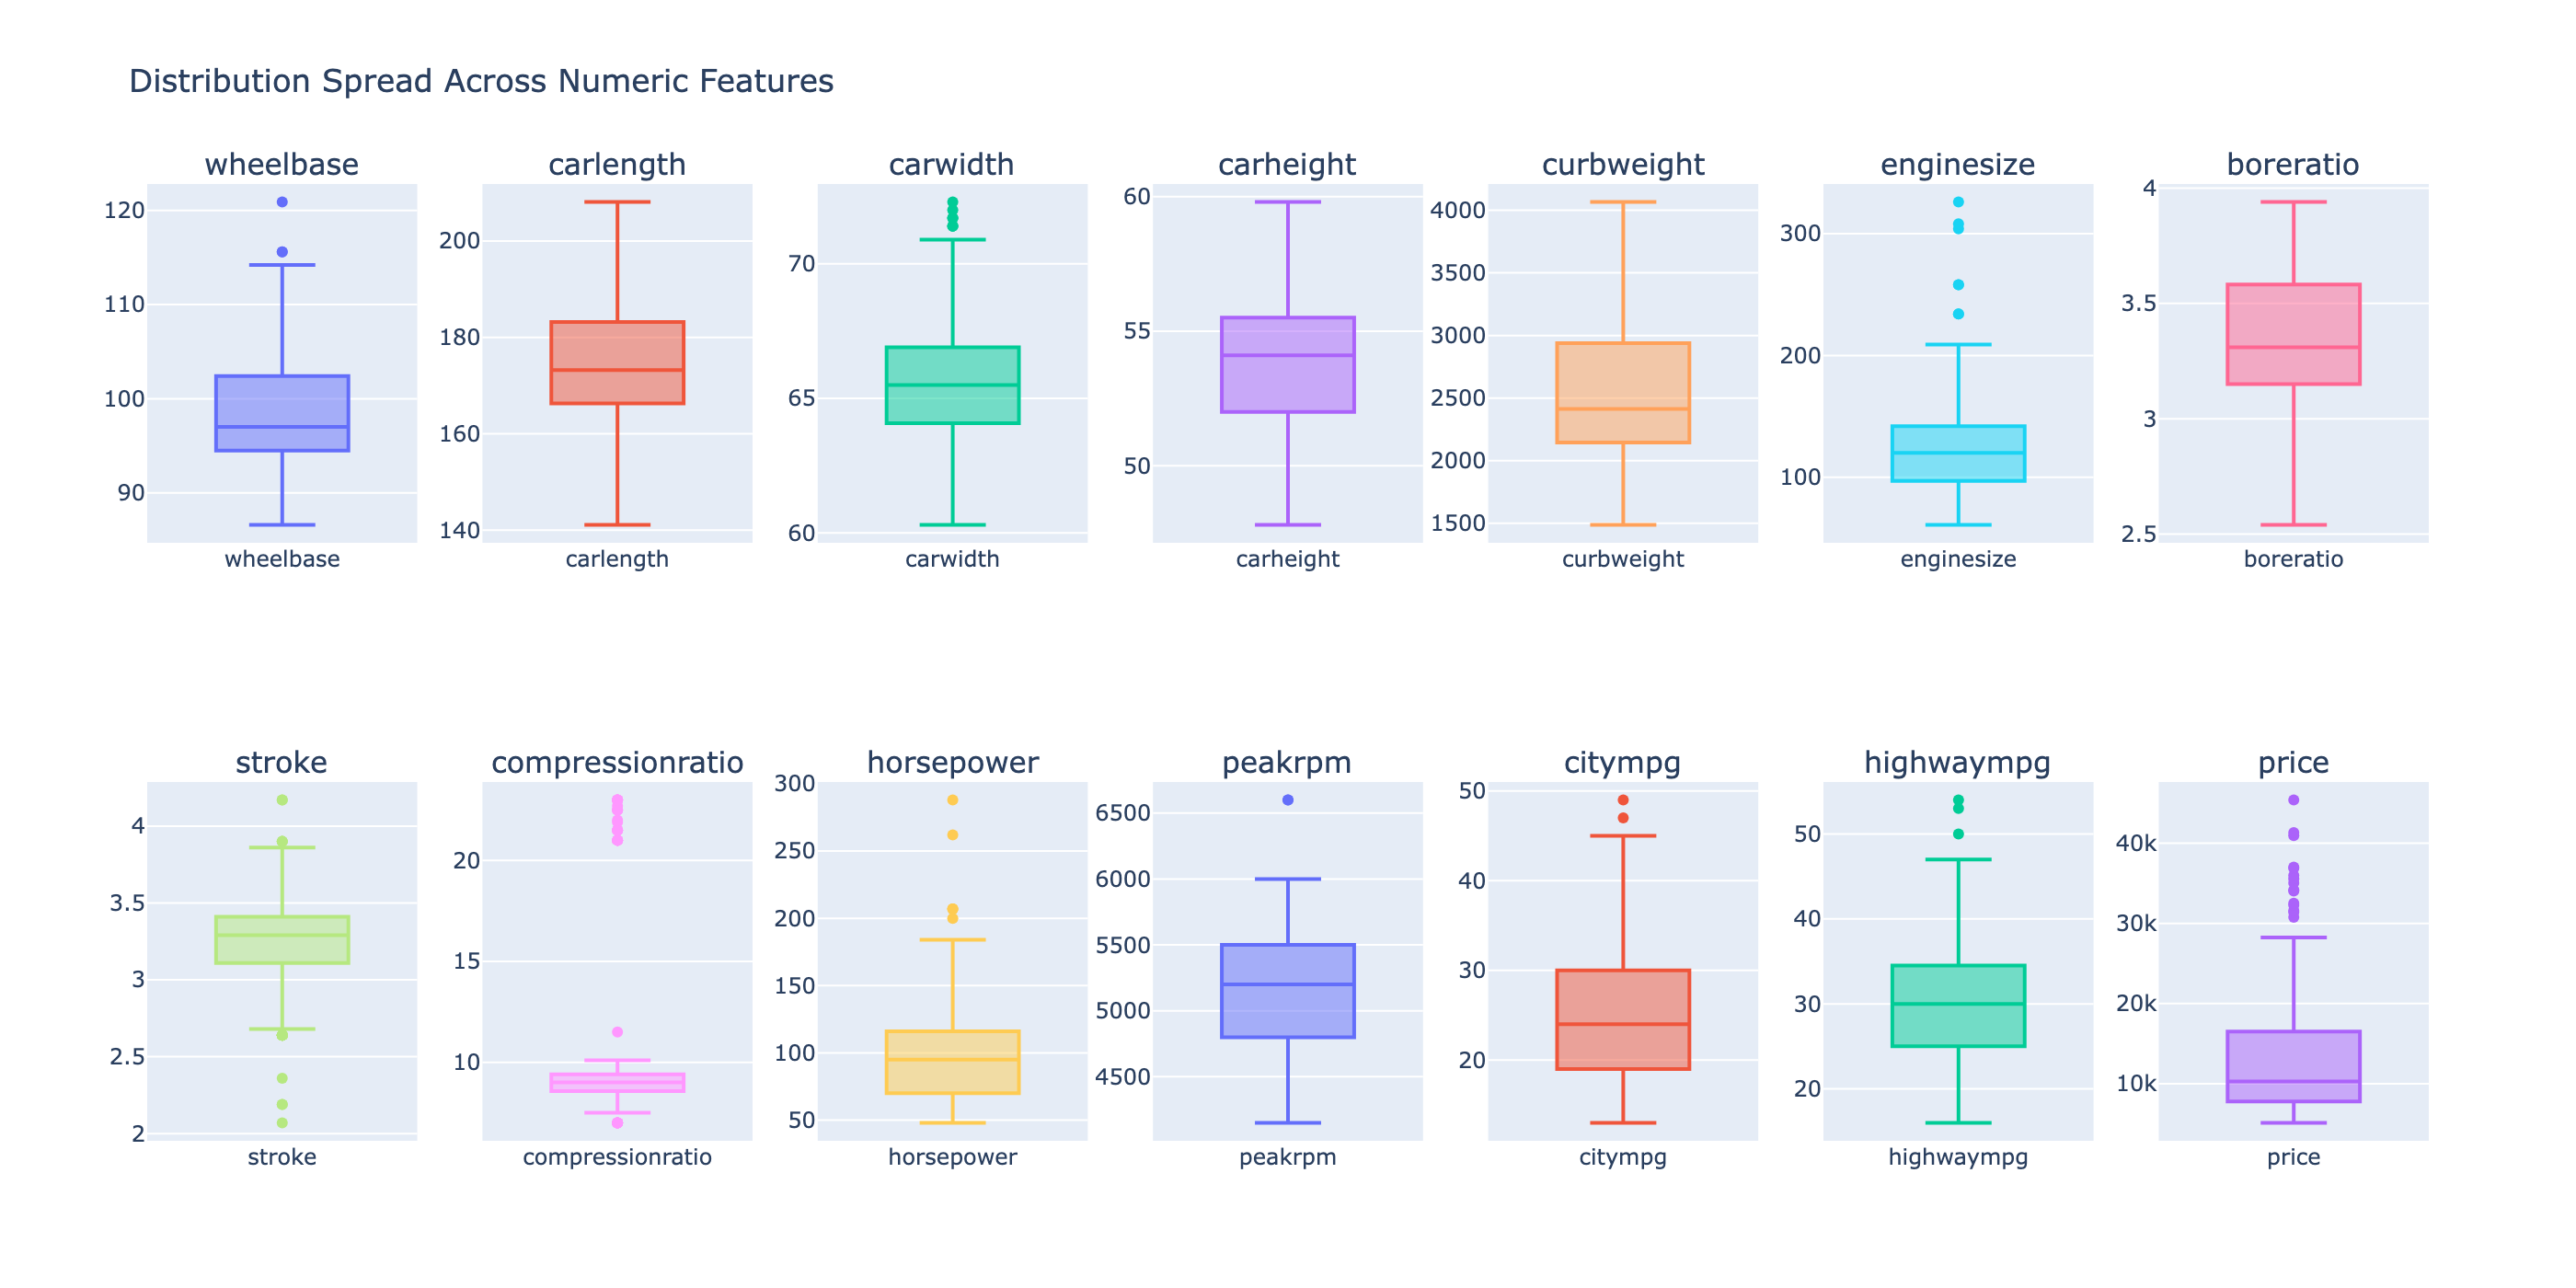

In [10]:
from plotly.subplots import make_subplots

fig = make_subplots(rows=2, cols=7, subplot_titles=numeric_cols)

for i, col in enumerate(numeric_cols):
    row = i // 7 + 1
    col_pos = i % 7 + 1
    fig.add_trace(go.Box(y=df[col], name=col, showlegend=False), row=row, col=col_pos)

fig.update_layout(
    title="Distribution Spread Across Numeric Features",
    height=700,
    width=1400
)

fig.write_image("../reports/figures/01_numeric_boxplots.png")
fig.show()

### Compression Ratio by Fuel Type

In [11]:
df.group_by("fueltype").agg(
    pl.col("compressionratio").min().alias("min"),
    pl.col("compressionratio").mean().round(2).alias("mean"),
    pl.col("compressionratio").max().alias("max"),
    pl.col("compressionratio").count().alias("count")
)

fueltype,min,mean,max,count
str,f64,f64,f64,u32
"""gas""",7.0,8.86,11.5,185
"""diesel""",21.0,22.01,23.0,20


### Duplicate Rows Check

In [12]:
n_duplicates = df.is_duplicated().sum()
print(f"Fully duplicated rows: {n_duplicates}")

n_duplicates_no_id = df.drop("car_ID").is_duplicated().sum()
print(f"Duplicated rows excluding car_ID: {n_duplicates_no_id}")

Fully duplicated rows: 0
Duplicated rows excluding car_ID: 0


### car_ID Integrity Check

In [13]:
print(f"Unique car_ID count: {df['car_ID'].n_unique()}")
print(f"Min: {df['car_ID'].min()}, Max: {df['car_ID'].max()}")
print(f"Expected range 1 to 205 with no gaps: {sorted(df['car_ID'].to_list()) == list(range(1, 206))}")

Unique car_ID count: 205
Min: 1, Max: 205
Expected range 1 to 205 with no gaps: True


### Grouping Rare Categories

In [14]:
RARE_THRESHOLD = 3

rare_group_cols = ["enginetype", "cylindernumber", "fuelsystem"]

for col in rare_group_cols:
    counts = df[col].value_counts()
    rare_values = counts.filter(pl.col("count") < RARE_THRESHOLD)[col].to_list()
    print(f"{col}: grouping {rare_values} into 'other'")
    df = df.with_columns(
        pl.when(pl.col(col).is_in(rare_values))
        .then(pl.lit("other"))
        .otherwise(pl.col(col))
        .alias(col)
    )

for col in rare_group_cols:
    print(df[col].value_counts().sort("count", descending=True))
    print()

enginetype: grouping ['dohcv'] into 'other'
cylindernumber: grouping ['three', 'twelve'] into 'other'
fuelsystem: grouping ['spfi', 'mfi'] into 'other'
shape: (7, 2)
┌────────────┬───────┐
│ enginetype ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ ohc        ┆ 148   │
│ ohcf       ┆ 15    │
│ ohcv       ┆ 13    │
│ l          ┆ 12    │
│ dohc       ┆ 12    │
│ rotor      ┆ 4     │
│ other      ┆ 1     │
└────────────┴───────┘

shape: (6, 2)
┌────────────────┬───────┐
│ cylindernumber ┆ count │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ four           ┆ 159   │
│ six            ┆ 24    │
│ five           ┆ 11    │
│ eight          ┆ 5     │
│ two            ┆ 4     │
│ other          ┆ 2     │
└────────────────┴───────┘

shape: (7, 2)
┌────────────┬───────┐
│ fuelsystem ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ mpfi       ┆ 94    │
│ 2bbl       ┆ 66    │
│ idi        ┆ 20   

### symboling Dtype Correction

In [15]:
symboling_order = ["-3", "-2", "-1", "0", "1", "2", "3"]

df = df.with_columns(
    pl.col("symboling")
    .cast(pl.Utf8)
    .cast(pl.Enum(symboling_order))
)

df["symboling"].dtype

Enum(categories=['-3', '-2', '-1', '0', '1', '2', '3'])

### CarName: Splitting Brand From Model

In [16]:
df = df.with_columns(
    pl.col("CarName").str.split(" ").list.first().str.to_lowercase().alias("brand")
)

sorted(df["brand"].unique().to_list())

['alfa-romero',
 'audi',
 'bmw',
 'buick',
 'chevrolet',
 'dodge',
 'honda',
 'isuzu',
 'jaguar',
 'maxda',
 'mazda',
 'mercury',
 'mitsubishi',
 'nissan',
 'peugeot',
 'plymouth',
 'porcshce',
 'porsche',
 'renault',
 'saab',
 'subaru',
 'toyota',
 'toyouta',
 'vokswagen',
 'volkswagen',
 'volvo',
 'vw']

### Brand Name Corrections

In [17]:
brand_corrections = {
    "maxda": "mazda",
    "porcshce": "porsche",
    "toyouta": "toyota",
    "vokswagen": "volkswagen",
    "vw": "volkswagen",
}

df = df.with_columns(
    pl.col("brand").replace(brand_corrections).alias("brand")
)

print(f"Unique brands after correction: {df['brand'].n_unique()}")
sorted(df["brand"].unique().to_list())

Unique brands after correction: 22


['alfa-romero',
 'audi',
 'bmw',
 'buick',
 'chevrolet',
 'dodge',
 'honda',
 'isuzu',
 'jaguar',
 'mazda',
 'mercury',
 'mitsubishi',
 'nissan',
 'peugeot',
 'plymouth',
 'porsche',
 'renault',
 'saab',
 'subaru',
 'toyota',
 'volkswagen',
 'volvo']

### Extracting Model From CarName

In [18]:
df = df.with_columns(
    pl.col("CarName")
    .str.split(" ")
    .list.slice(1)
    .list.join(" ")
    .str.to_lowercase()
    .alias("model")
)

df.select("CarName", "brand", "model").head(10)

CarName,brand,model
str,str,str
"""alfa-romero giulia""","""alfa-romero""","""giulia"""
"""alfa-romero stelvio""","""alfa-romero""","""stelvio"""
"""alfa-romero Quadrifoglio""","""alfa-romero""","""quadrifoglio"""
"""audi 100 ls""","""audi""","""100 ls"""
"""audi 100ls""","""audi""","""100ls"""
"""audi fox""","""audi""","""fox"""
"""audi 100ls""","""audi""","""100ls"""
"""audi 5000""","""audi""","""5000"""
"""audi 4000""","""audi""","""4000"""


### Verifying No Information Lost Against CarName

In [19]:
reconstructed = df.select(
    (pl.col("brand") + " " + pl.col("model")).alias("reconstructed"),
    pl.col("CarName").str.to_lowercase().alias("carname_lower")
)

mismatches = reconstructed.filter(pl.col("reconstructed") != pl.col("carname_lower"))
print(f"Mismatches: {mismatches.height}")
mismatches

Mismatches: 9


reconstructed,carname_lower
str,str
"""mazda rx3""","""maxda rx3"""
"""mazda glc deluxe""","""maxda glc deluxe"""
"""porsche panamera""","""porcshce panamera"""
"""subaru ""","""subaru"""
"""subaru ""","""subaru"""
"""toyota tercel""","""toyouta tercel"""
"""volkswagen rabbit""","""vokswagen rabbit"""
"""volkswagen dasher""","""vw dasher"""
"""volkswagen rabbit""","""vw rabbit"""


### Dropping CarName

In [20]:
df = df.drop("CarName")
df.select("brand", "model").head(3)

brand,model
str,str
"""alfa-romero""","""giulia"""
"""alfa-romero""","""stelvio"""
"""alfa-romero""","""quadrifoglio"""


### Final Cleaning Verification

In [21]:
print(f"Shape: {df.shape}")
print(f"Null count total: {df.null_count().sum_horizontal().sum()}")
print()
print(df.schema)

Shape: (205, 27)
Null count total: 0

Schema({'car_ID': Int64, 'symboling': Enum(categories=['-3', '-2', '-1', '0', '1', '2', '3']), 'fueltype': String, 'aspiration': String, 'doornumber': String, 'carbody': String, 'drivewheel': String, 'enginelocation': String, 'wheelbase': Float64, 'carlength': Float64, 'carwidth': Float64, 'carheight': Float64, 'curbweight': Int64, 'enginetype': String, 'cylindernumber': String, 'enginesize': Int64, 'fuelsystem': String, 'boreratio': Float64, 'stroke': Float64, 'compressionratio': Float64, 'horsepower': Int64, 'peakrpm': Int64, 'citympg': Int64, 'highwaympg': Int64, 'price': Float64, 'brand': String, 'model': String})


## Train Test Split

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop("price")
y = df.select("price")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=RANDOM_SEED
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (137, 26), X_test: (68, 26)
y_train: (137, 1), y_test: (68, 1)


### Checking Rare Category Distribution After Split

In [23]:
check_cols = ["enginetype", "cylindernumber", "fuelsystem", "enginelocation", "drivewheel", "carbody"]

for col in check_cols:
    train_vals = set(X_train[col].unique().to_list())
    test_vals = set(X_test[col].unique().to_list())
    only_in_test = test_vals - train_vals
    only_in_train = train_vals - test_vals
    if only_in_test or only_in_train:
        print(f"{col}: only in test {only_in_test}, only in train {only_in_train}")


enginetype: only in test set(), only in train {'other'}


## Exploratory Data Analysis (Full Pass)

### Target Distribution: Price

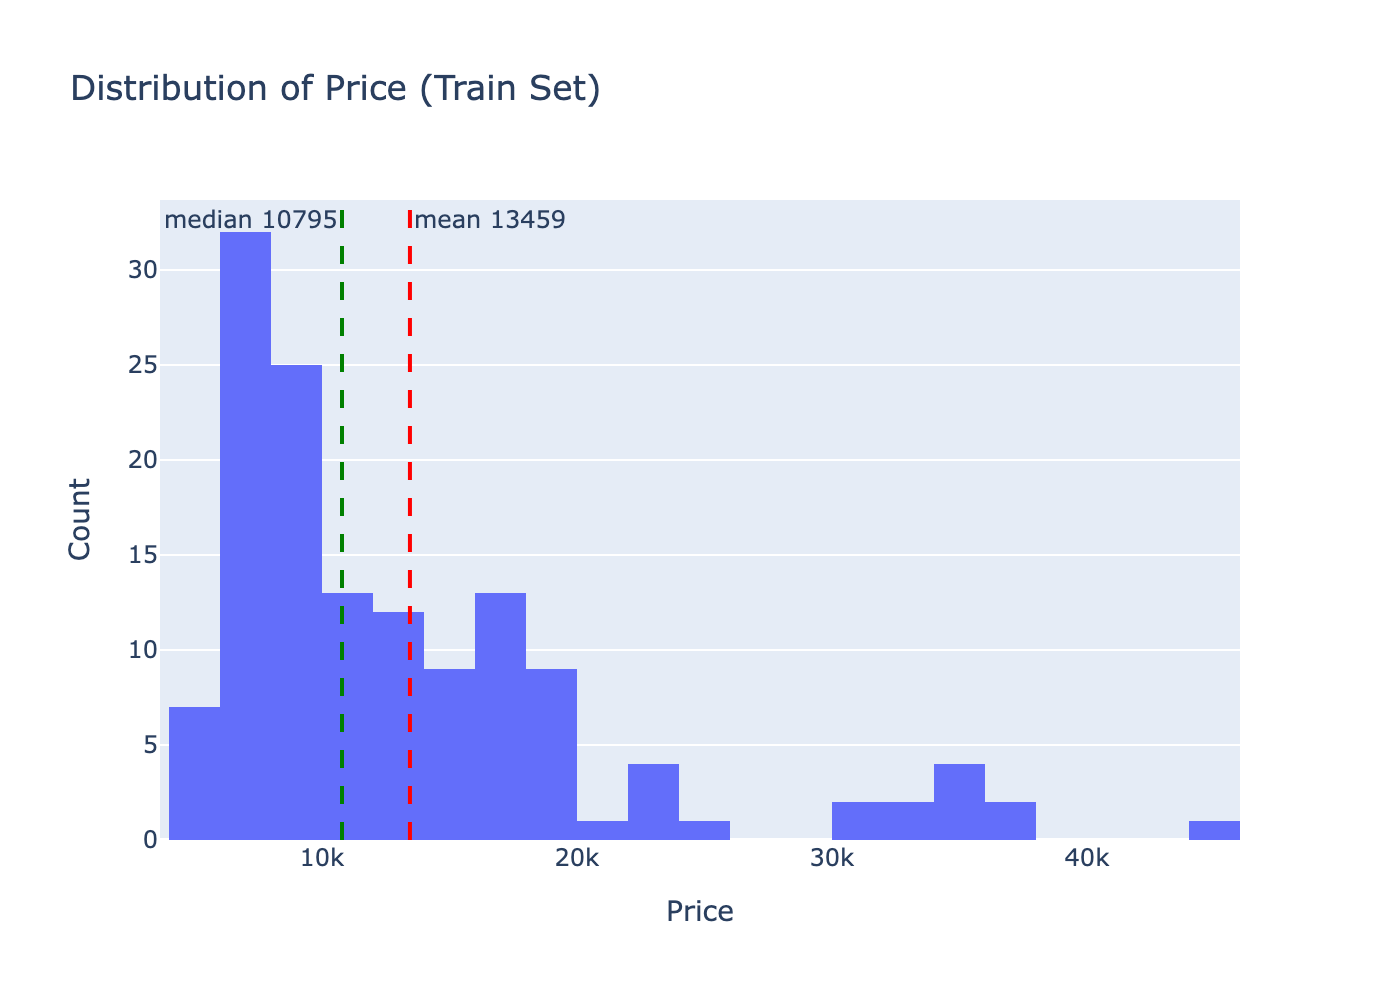

In [24]:
price_mean = y_train["price"].mean()
price_median = y_train["price"].median()

fig = go.Figure()
fig.add_trace(go.Histogram(x=y_train["price"], nbinsx=30, name="price"))
fig.add_vline(x=price_mean, line_dash="dash", line_color="red",
              annotation_text=f"mean {price_mean:.0f}",
              annotation_position="top right")
fig.add_vline(x=price_median, line_dash="dash", line_color="green",
              annotation_text=f"median {price_median:.0f}",
              annotation_position="top left")

fig.update_layout(
    title="Distribution of Price (Train Set)",
    xaxis_title="Price",
    yaxis_title="Count",
    height=500
)

fig.write_image("../reports/figures/02_price_distribution.png")
fig.show()

### Distributions of Skewed Numeric Features

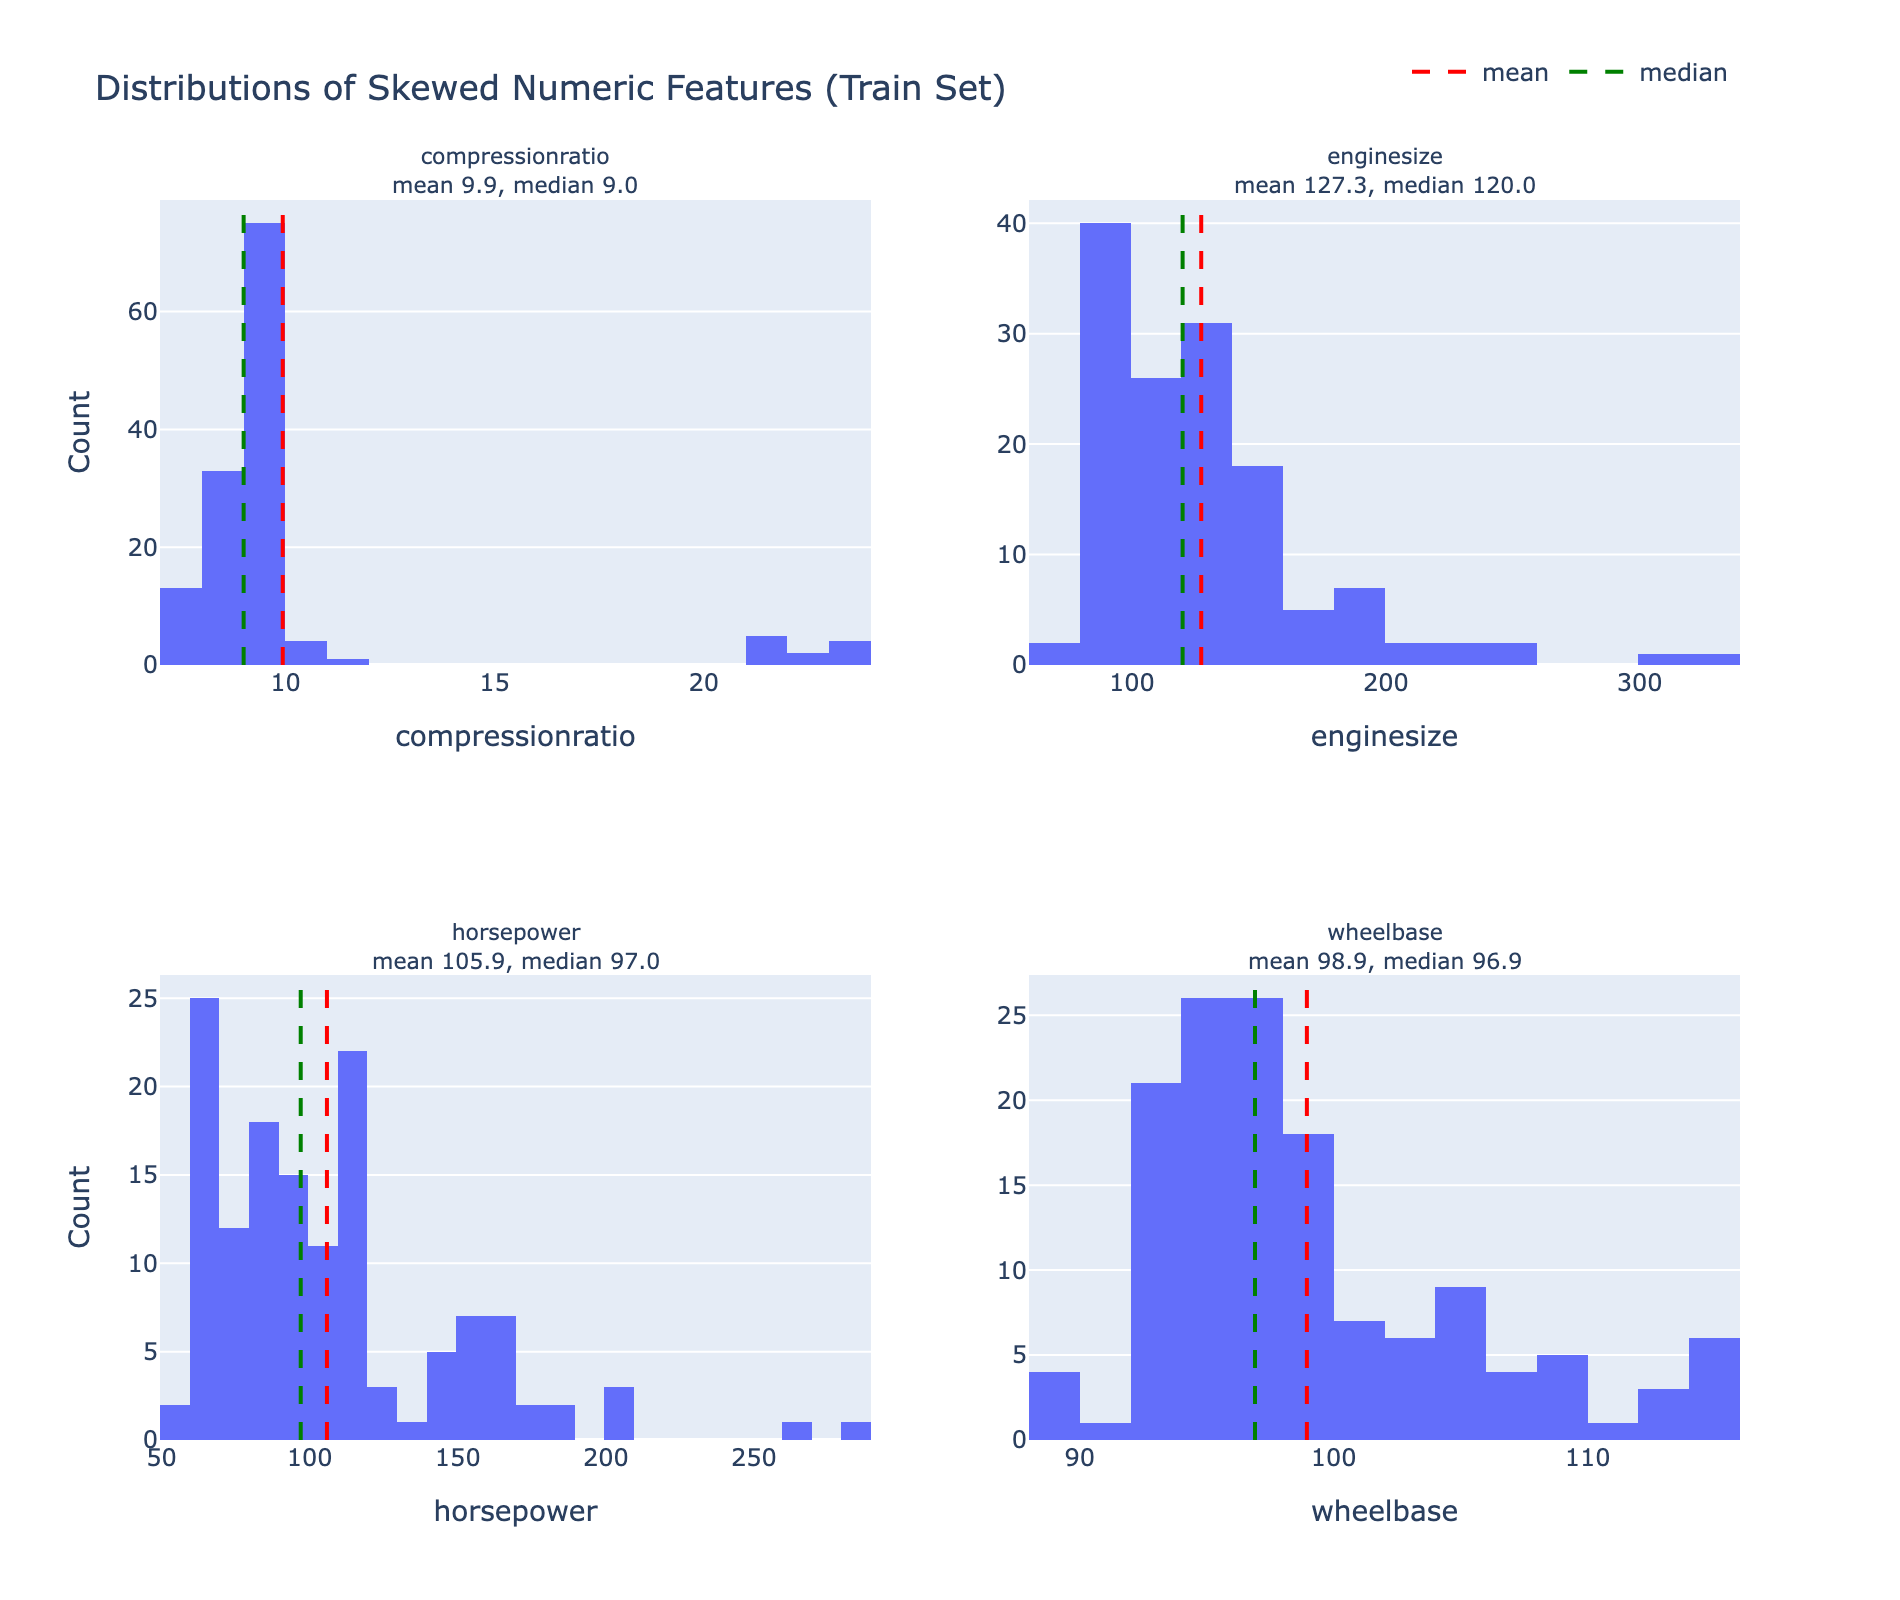

In [25]:
from plotly.subplots import make_subplots

skewed_cols = ["compressionratio", "enginesize", "horsepower", "wheelbase"]
positions = [(1, 1), (1, 2), (2, 1), (2, 2)]

subplot_titles = []
stats = {}
for col in skewed_cols:
    col_mean = X_train[col].mean()
    col_median = X_train[col].median()
    stats[col] = (col_mean, col_median)
    subplot_titles.append(f"{col}<br>mean {col_mean:.1f}, median {col_median:.1f}")

fig = make_subplots(rows=2, cols=2, subplot_titles=subplot_titles)

for i, (col, (row, col_pos)) in enumerate(zip(skewed_cols, positions)):
    col_mean, col_median = stats[col]
    show_legend = (i == 0)

    fig.add_trace(
        go.Histogram(x=X_train[col], nbinsx=25, name=col,
                     marker_color="#636EFA", showlegend=False),
        row=row, col=col_pos
    )
    fig.add_vline(x=col_mean, line_dash="dash", line_color="red",
                  row=row, col=col_pos)
    fig.add_vline(x=col_median, line_dash="dash", line_color="green",
                  row=row, col=col_pos)
    fig.add_trace(
        go.Scatter(x=[None], y=[None], mode="lines",
                    line=dict(color="red", dash="dash"), name="mean",
                    showlegend=show_legend),
        row=row, col=col_pos
    )
    fig.add_trace(
        go.Scatter(x=[None], y=[None], mode="lines",
                    line=dict(color="green", dash="dash"), name="median",
                    showlegend=show_legend),
        row=row, col=col_pos
    )

fig.update_xaxes(title_text="compressionratio", row=1, col=1)
fig.update_xaxes(title_text="enginesize", row=1, col=2)
fig.update_xaxes(title_text="horsepower", row=2, col=1)
fig.update_xaxes(title_text="wheelbase", row=2, col=2)
fig.update_yaxes(title_text="Count", col=1)

fig.update_layout(
    title="Distributions of Skewed Numeric Features (Train Set)",
    height=800,
    width=950,
    legend=dict(orientation="h", yanchor="bottom", y=1.08, xanchor="right", x=1)
)

fig.update_annotations(font_size=11)

fig.write_image("../reports/figures/03_skewed_features_distribution.png")
fig.show()

### Correlation Heatmap

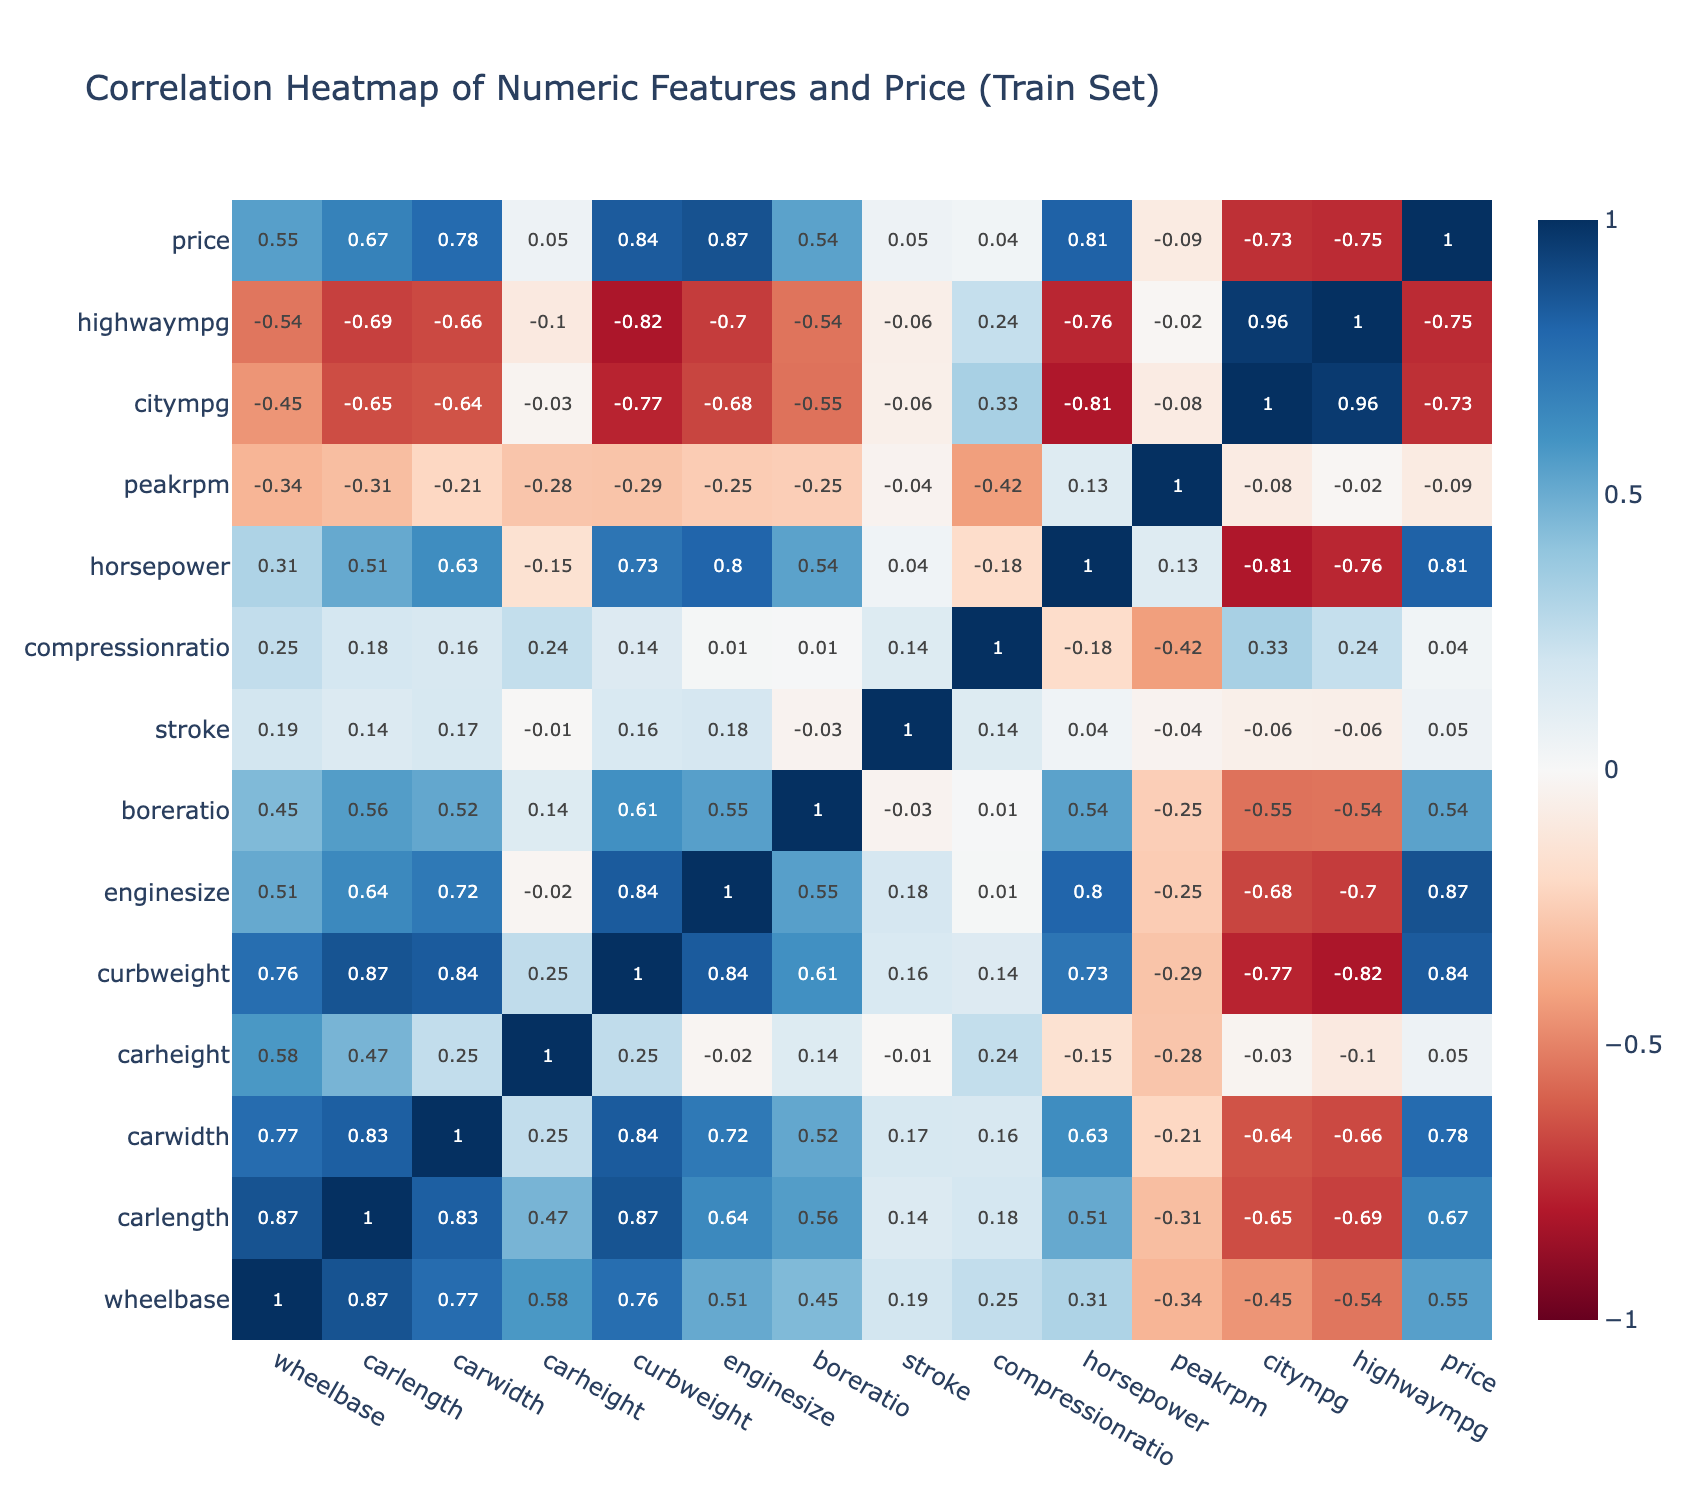

In [26]:
numeric_cols = [
    "wheelbase", "carlength", "carwidth", "carheight", "curbweight",
    "enginesize", "boreratio", "stroke", "compressionratio",
    "horsepower", "peakrpm", "citympg", "highwaympg"
]

train_with_price = X_train.select(numeric_cols).with_columns(y_train["price"])
corr_matrix = train_with_price.to_pandas().corr()

fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale="RdBu",
    zmid=0,
    text=corr_matrix.round(2).values,
    texttemplate="%{text}",
    textfont={"size": 9}
))

fig.update_layout(
    title="Correlation Heatmap of Numeric Features and Price (Train Set)",
    height=750,
    width=850
)

fig.write_image("../reports/figures/04_correlation_heatmap.png")
fig.show()

### Variance Inflation Factor (VIF)

In [27]:
from statsmodels.tools.tools import add_constant

vif_cols = [
    "wheelbase", "carlength", "carwidth", "carheight", "curbweight",
    "enginesize", "boreratio", "stroke", "compressionratio",
    "horsepower", "peakrpm", "citympg", "highwaympg"
]

X_vif = add_constant(X_train.select(vif_cols).to_pandas())

vif_data = pl.DataFrame({
    "feature": vif_cols,
    "VIF": [
        variance_inflation_factor(X_vif.values, i + 1)
        for i in range(len(vif_cols))
    ]
}).sort("VIF", descending=True)

vif_data

feature,VIF
str,f64
"""citympg""",25.97056
"""highwaympg""",20.245001
"""curbweight""",16.39829
"""carlength""",9.189574
"""horsepower""",8.158647
…,…
"""compressionratio""",2.23059
"""peakrpm""",2.146962
"""carheight""",2.134843


### Multicollinearity Case Study: citympg, highwaympg, curbweight

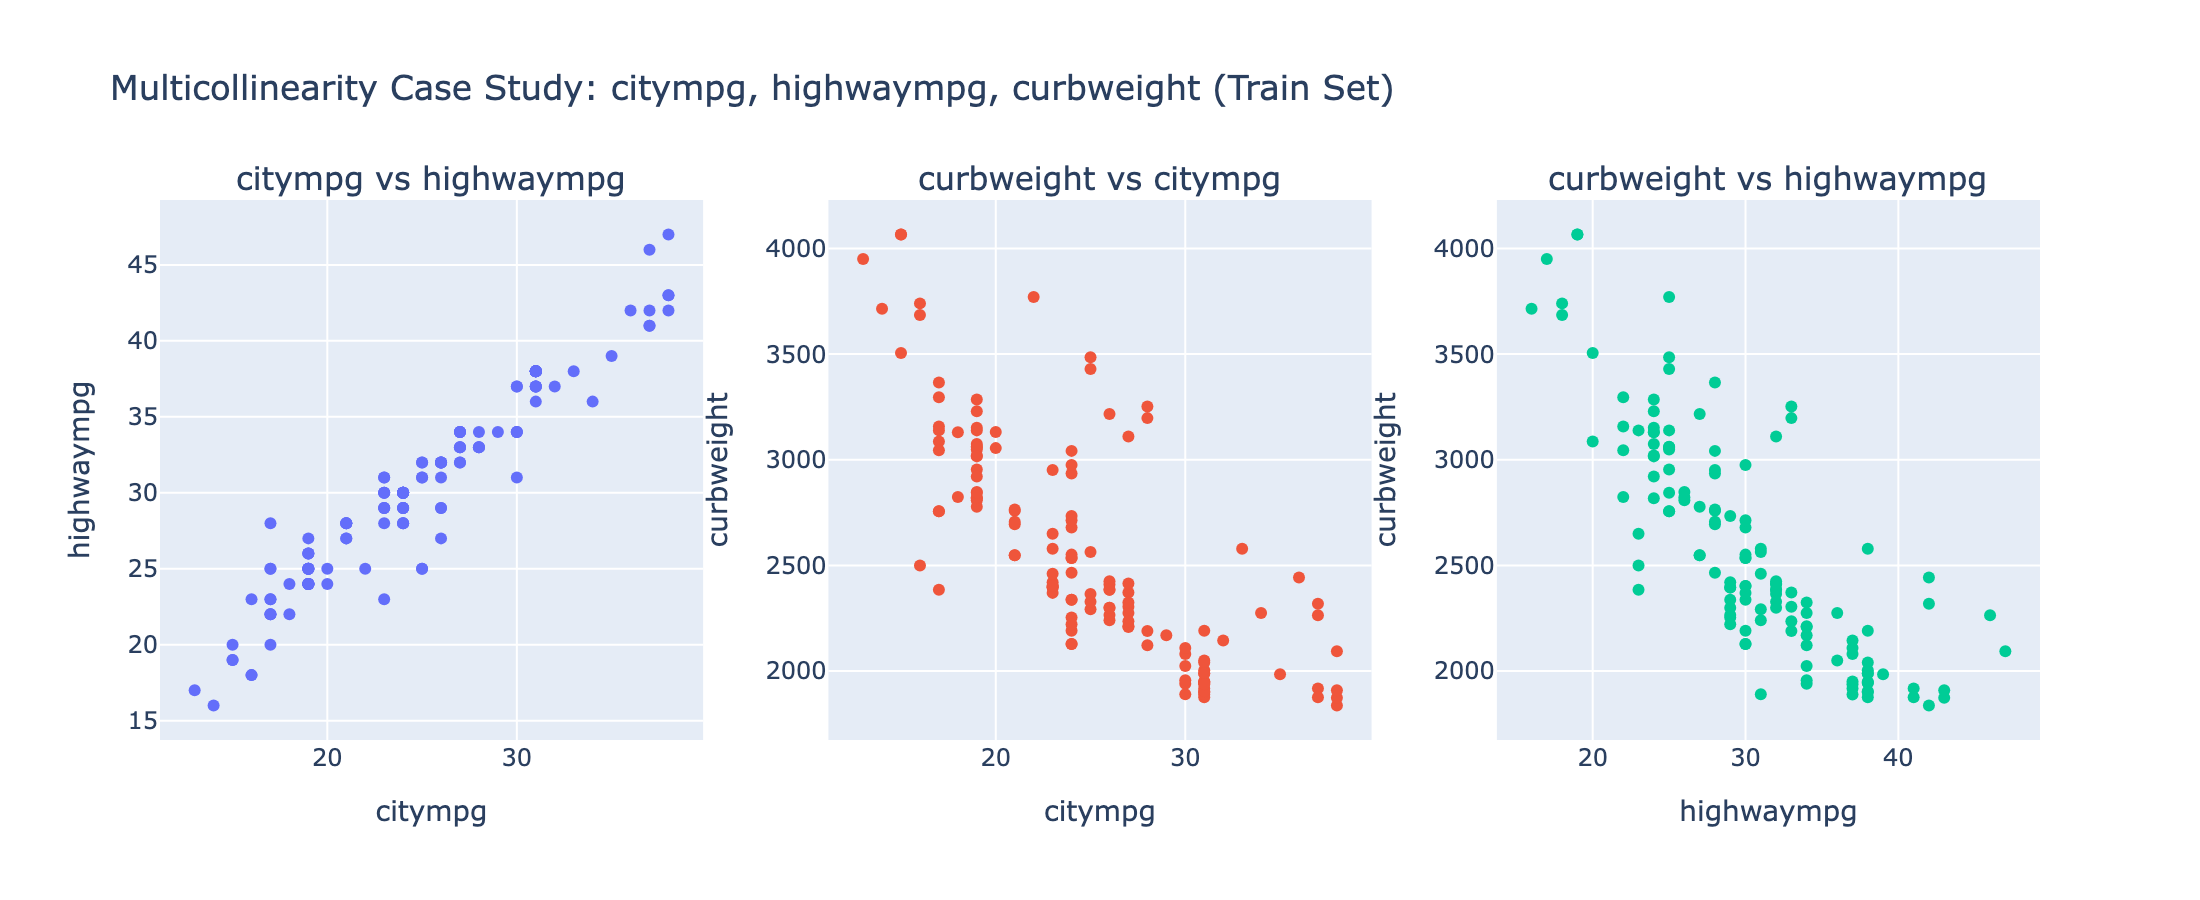

In [28]:
case_study_cols = ["citympg", "highwaympg", "curbweight"]

fig = make_subplots(rows=1, cols=3, subplot_titles=[
    "citympg vs highwaympg",
    "curbweight vs citympg",
    "curbweight vs highwaympg"
])

fig.add_trace(
    go.Scatter(x=X_train["citympg"], y=X_train["highwaympg"], mode="markers",
               marker_color="#636EFA", showlegend=False),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=X_train["citympg"], y=X_train["curbweight"], mode="markers",
               marker_color="#EF553B", showlegend=False),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(x=X_train["highwaympg"], y=X_train["curbweight"], mode="markers",
               marker_color="#00CC96", showlegend=False),
    row=1, col=3
)

fig.update_xaxes(title_text="citympg", row=1, col=1)
fig.update_yaxes(title_text="highwaympg", row=1, col=1)
fig.update_xaxes(title_text="citympg", row=1, col=2)
fig.update_yaxes(title_text="curbweight", row=1, col=2)
fig.update_xaxes(title_text="highwaympg", row=1, col=3)
fig.update_yaxes(title_text="curbweight", row=1, col=3)

fig.update_layout(
    title="Multicollinearity Case Study: citympg, highwaympg, curbweight (Train Set)",
    height=450,
    width=1100
)

fig.write_image("../reports/figures/05_multicollinearity_case_study.png")
fig.show()

### Case Study Summary Statistics

In [29]:
case_study_corr = corr_matrix.loc[case_study_cols, case_study_cols].round(3)
print("Pairwise correlations:")
print(case_study_corr)
print()

case_study_vif = vif_data.filter(pl.col("feature").is_in(case_study_cols))
print("VIF (computed against all 13 numeric predictors, not just these 3):")
case_study_vif

Pairwise correlations:
            citympg  highwaympg  curbweight
citympg       1.000       0.961      -0.769
highwaympg    0.961       1.000      -0.816
curbweight   -0.769      -0.816       1.000

VIF (computed against all 13 numeric predictors, not just these 3):


feature,VIF
str,f64
"""citympg""",25.97056
"""highwaympg""",20.245001
"""curbweight""",16.39829
